🔹 Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, f_classif

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

🔹 Load Dataset

In [2]:
df = pd.read_csv("C:/Users/shrey/Downloads/REM/Parkinsons-Multimodal-Framework/datasets/REM/dataset.csv")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Display first 5 rows and column names
print("Column names:")
print(df.columns.tolist())
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Column names:
['Participant  code', 'Age  (years)', 'Gender', 'Positive  history  of  Parkinson  disease  in  family', 'Age  of  disease  onset  (years)', 'Duration  of  disease  from  first  symptoms  (years)', 'Antidepressant  therapy', 'Antiparkinsonian  medication', 'Antipsychotic  medication', 'Benzodiazepine  medication', 'Levodopa  equivalent  (mg/day)', 'Clonazepam  (mg/day)', 'Overview  of  motor  examination:  Hoehn  &  Yahr  scale  (-)', 'Overview  of  motor  examination:  UPDRS  III  total  (-)', '18.  Speech', '19.  Facial  Expression', '20.  Tremor  at  Rest  -  head', '20.  Tremor  at  Rest  -  RUE', '20.  Tremor  at  Rest  -  LUE', '20.  Tremor  at  Rest  -  RLE', '20.  Tremor  at  Rest  -  LLE', '21.  Action  or  Postural  Tremor  -  RUE', '21.  Action  or  Postural  Tremor  -  LUE', '22.  Rigidity  -  neck', '22.  Rigidity  -  RUE', '22.  Rigidity  -  LUE', '22.  Rigidity  -  RLE', '22.  Rigidity  -  LLE', '23.Finger  Taps  -  RUE', '23.Finger  Taps  -  LUE', '24.  Ha

,Participant code,Age (years),Gender,Positive history of Parkinson disease in family,Age of disease onset (years),Duration of disease from first symptoms (years),Antidepressant therapy,Antiparkinsonian medication,Antipsychotic medication,Benzodiazepine medication,...,Acceleration of speech timing (-/min2) .1,Duration of pause intervals (ms) .1,Duration of voiced intervals (ms) .1,Gaping in-between voiced Intervals (-/min),Duration of unvoiced stops (ms) .1,Decay of unvoiced fricatives (‰/min) .1,Relative loudness of respiration (dB) .1,Pause intervals per respiration (-) .1,Rate of speech respiration (-/min) .1,Latency of respiratory exchange (ms) .1
0,PD01,58,F,No,56,2,No,No,No,No,...,-2.82,158,318,49.01,22.37,0.588,-19.77,6.0,13.81,127
1,PD02,68,F,No,67,1,No,No,No,No,...,8.20,295,264,40.56,26.88,-0.825,-23.26,4.0,21.77,313
2,PD03,68,M,No,67,1,No,No,No,No,...,4.71,280,317,48.97,22.37,-0.955,-13.29,4.0,22.52,201
3,PD04,75,M,No,73,2,No,No,No,No,...,-9.09,397,800,18.69,49.37,0.791,-25.08,2.0,14.37,151
4,PD05,61,M,Yes,60,0.7,No,No,No,No,...,11.77,206,480,33.54,26.87,0.075,-22.32,5.0,14.61,151


🔹 Data Preprocessing
Convert Target Variable

In [4]:
target_col = 'Positive  history  of  Parkinson  disease  in  family'

df[target_col] = df[target_col].map({
    'Yes': 1,
    'No': 0
})

print(f"Target column '{target_col}' converted to numeric")
print(df[target_col].value_counts())


Target column 'Positive  history  of  Parkinson  disease  in  family' converted to numeric
Positive  history  of  Parkinson  disease  in  family
0.0    77
1.0     3
Name: count, dtype: int64


Encode Categorical Columns

In [5]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

print(f"Categorical columns found: {categorical_cols}")

le = LabelEncoder()

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        
print("Categorical columns encoded successfully")


Categorical columns found: ['Participant  code', 'Gender', 'Age  of  disease  onset  (years)', 'Duration  of  disease  from  first  symptoms  (years)', 'Antidepressant  therapy', 'Antiparkinsonian  medication', 'Antipsychotic  medication', 'Benzodiazepine  medication', 'Overview  of  motor  examination:  Hoehn  &  Yahr  scale  (-)', 'Overview  of  motor  examination:  UPDRS  III  total  (-)', '18.  Speech', '19.  Facial  Expression', '20.  Tremor  at  Rest  -  head', '20.  Tremor  at  Rest  -  RUE', '20.  Tremor  at  Rest  -  LUE', '20.  Tremor  at  Rest  -  RLE', '20.  Tremor  at  Rest  -  LLE', '21.  Action  or  Postural  Tremor  -  RUE', '21.  Action  or  Postural  Tremor  -  LUE', '22.  Rigidity  -  neck', '22.  Rigidity  -  RUE', '22.  Rigidity  -  LUE', '22.  Rigidity  -  RLE', '22.  Rigidity  -  LLE', '23.Finger  Taps  -  RUE', '23.Finger  Taps  -  LUE', '24.  Hand  Movements  -  RUE', '24.  Hand  Movements  -  LUE', '25.  Rapid  Alternating  Movements  -  RUE', '25.  Rapid  Alt

Drop Unnecessary Column

In [6]:
cols_to_drop = ['Participant code']
df.drop([col for col in cols_to_drop if col in df.columns], axis=1, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"Dataset shape after dropping: {df.shape}")


Dropped columns: ['Participant code']
Dataset shape after dropping: (130, 65)


🔹 Split Data

In [8]:
target_col = 'Positive  history  of  Parkinson  disease  in  family'

# Remove rows with missing target values
df_clean = df.dropna(subset=[target_col])

X = df_clean.drop(target_col, axis=1)
y = df_clean[target_col]

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Feature matrix shape: (80, 64)
Target variable shape: (80,)

Target distribution:
Positive  history  of  Parkinson  disease  in  family
0.0    77
1.0     3
Name: count, dtype: int64

Training set size: 64
Test set size: 16


Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Handle Imbalanced Data (SMOTE)

In [14]:
print("Class distribution in training set:")
print(y_train.value_counts())

# Get minority class size
minority_class_size = y_train.value_counts().min()
print(f"\nMinority class size: {minority_class_size}")

# Apply SMOTE only if minority class has enough samples
if minority_class_size > 1:
    # Adjust k_neighbors based on minority class size
    k_neighbors = min(5, minority_class_size - 1)
    print(f"Applying SMOTE with k_neighbors={k_neighbors}")
    
    sm = SMOTE(k_neighbors=k_neighbors, random_state=42)
    X_train, y_train = sm.fit_resample(X_train, y_train)
    
    print("SMOTE applied successfully")
else:
    print("Minority class too small for SMOTE - skipping resampling")

print(f"\nClass distribution after processing:")
print(y_train.value_counts())


Class distribution in training set:
Positive  history  of  Parkinson  disease  in  family
0.0    62
1.0     2
Name: count, dtype: int64

Minority class size: 2
Applying SMOTE with k_neighbors=1
SMOTE applied successfully

Class distribution after processing:
Positive  history  of  Parkinson  disease  in  family
0.0    62
1.0    62
Name: count, dtype: int64


Feature Selection

In [15]:
selector = SelectKBest(score_func=f_classif, k=30)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [6 7 9] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Train Model (XGBoost)

In [16]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

Predictions

In [17]:
y_pred = model.predict(X_test)

Evaluation

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9375

Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      1.00      0.97        15
         1.0       0.00      0.00      0.00         1

    accuracy                           0.94        16
   macro avg       0.47      0.50      0.48        16
weighted avg       0.88      0.94      0.91        16



c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

DETAILED ACCURACY ANALYSIS

Confusion Matrix:
True Negatives (TN):  15
False Positives (FP): 0
False Negatives (FN): 1
True Positives (TP):  0

Derived Metrics:
Sensitivity (Recall): 0.0000
Specificity:          1.0000
Precision:            0.0000
F1-Score:             0.0000

⚠️ MODEL ANALYSIS:
- Model predicts ALL samples as class 0 (no family history)
- Total test samples: 16
- Samples with family history (class 1): 1
- Samples without family history (class 0): 15

🔴 ISSUE: The model has learned class imbalance bias and ignores positive cases!


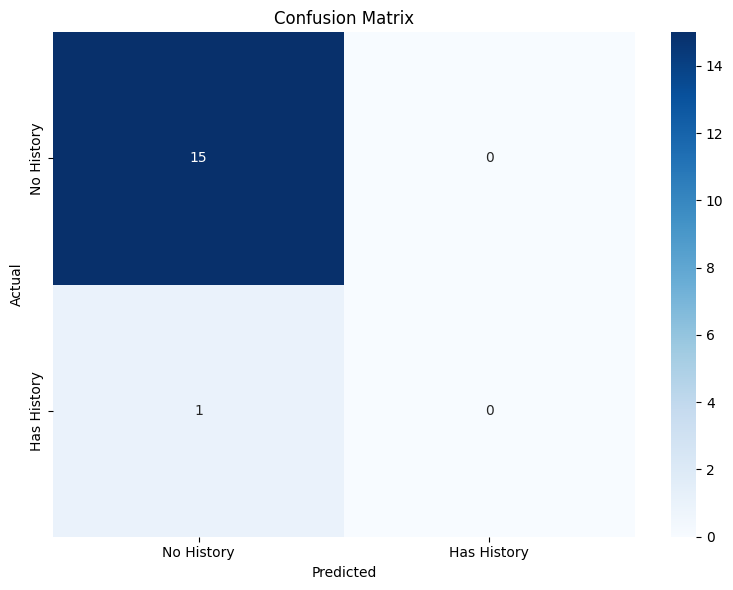

In [20]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

import matplotlib.pyplot as plt

# Get detailed metrics
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("DETAILED ACCURACY ANALYSIS")
print("=" * 60)

print(f"\nConfusion Matrix:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

print(f"\nDerived Metrics:")
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"F1-Score:             {f1:.4f}")

print("\n⚠️ MODEL ANALYSIS:")
print(f"- Model predicts ALL samples as class 0 (no family history)")
print(f"- Total test samples: {len(y_test)}")
print(f"- Samples with family history (class 1): {sum(y_test == 1)}")
print(f"- Samples without family history (class 0): {sum(y_test == 0)}")
print(f"\n🔴 ISSUE: The model has learned class imbalance bias and ignores positive cases!")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No History', 'Has History'],
            yticklabels=['No History', 'Has History'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Hyperparameter Tuning

In [19]:
params = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100}
